In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# ADIM 1: İşlenmiş Verileri Yükleme
# ---------------------------------------------------------
print("İşlenmiş veriler yükleniyor...")
X_train = pd.read_csv("../data/processed/X_train_processed.csv", index_col='id')
y_train = pd.read_csv("../data/processed/y_train_processed.csv", index_col='id')['Churn'] 
X_test = pd.read_csv("../data/processed/X_test_processed.csv", index_col='id')

print("\n--- İLERİ SEVİYE: Yeni Öznitelikler (Features) Üretiliyor ---")

# Her ihtimale karşı 'TotalCharges'ın sıfıra bölünmesini engellemek için tenure'a 1 ekliyoruz
# 1. Finansal Ağırlık: Müşterinin ayda ortalama ne kadar ödediğini bulalım
X_train['Avg_Monthly_Spend'] = X_train['TotalCharges'] / (X_train['tenure'] + 1)
X_test['Avg_Monthly_Spend'] = X_test['TotalCharges'] / (X_test['tenure'] + 1)

# 2. Yüksek Risk Kombinasyonu: Grafikteki en önemli 2 özelliği birleştiriyoruz!
# Hem Fiber Optik kullanıp hem de Elektronik Çek ile ödeyenler (Muhtemelen en çok kaçanlar)
if 'InternetService_Fiber optic' in X_train.columns and 'PaymentMethod_Electronic check' in X_train.columns:
    X_train['High_Risk_Combo'] = ((X_train['InternetService_Fiber optic'] == 1) & 
                                  (X_train['PaymentMethod_Electronic check'] == 1)).astype(int)
    X_test['High_Risk_Combo'] = ((X_test['InternetService_Fiber optic'] == 1) & 
                                 (X_test['PaymentMethod_Electronic check'] == 1)).astype(int)

# 3. Sadakat Çarpanı: Süre (tenure) ile 2 Yıllık Sözleşmeyi çarpıyoruz (En sadık müşterileri vurgulamak için)
if 'Contract_Two year' in X_train.columns:
    X_train['Loyalty_Score'] = X_train['tenure'] * X_train['Contract_Two year']
    X_test['Loyalty_Score'] = X_test['tenure'] * X_test['Contract_Two year']

print("Yeni eklenen özelliklerle birlikte Eğitim Seti boyutu:", X_train.shape)
# ---------------------------------------------------------
# ADIM 2: Çapraz Doğrulama (Cross-Validation) Kurulumu
# ---------------------------------------------------------
# Churn oranını (%77 No - %22 Yes) her fold'da korumak için StratifiedKFold kullanıyoruz.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tahminleri tutacağımız boş diziler
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

print("\nModel eğitimi başlıyor (5 Fold)...\n")

# ---------------------------------------------------------
# ADIM 3: XGBoost Model Eğitimi
# ---------------------------------------------------------
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]
    
    # Profesyonel bir başlangıç için temel hiperparametreler
    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="auc" # Yarışmanın bizden istediği metrik
    )
    
    # Modeli eğitiyoruz
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False # Çıktı kalabalığını önlemek için False yapıyoruz
    )
    
    # Doğrulama seti tahmini (Kaggle bizden direkt 0-1 değil, ayrılma "olasılığını" istiyor)
    valid_preds = model.predict_proba(X_va)[:, 1]
    oof_preds[valid_idx] = valid_preds
    
    # Test seti tahminlerini toplayıp ortalamasını alacağız
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    # Her fold'un başarısını ölçüyoruz
    fold_auc = roc_auc_score(y_va, valid_preds)
    print(f"Fold {fold+1} AUC Skoru: {fold_auc:.4f}")

# ---------------------------------------------------------
# ADIM 4: Genel Başarı ve Kaggle Dosyası Oluşturma
# ---------------------------------------------------------
cv_auc = roc_auc_score(y_train, oof_preds)
print(f"\n🏆 Ortalama Cross-Validation (OOF) AUC Skoru: {cv_auc:.4f}")

# Kaggle için formatlama
submission = pd.DataFrame({
    'id': X_test.index,
    'Churn': test_preds
})

# submissions klasörüne kaydediyoruz
submission.to_csv("../submissions/submission_xgboost_baseline.csv", index=False)
print("\n✅ Kaggle gönderim dosyası 'submissions' klasörüne başarıyla kaydedildi!")

İşlenmiş veriler yükleniyor...

--- İLERİ SEVİYE: Yeni Öznitelikler (Features) Üretiliyor ---
Yeni eklenen özelliklerle birlikte Eğitim Seti boyutu: (594194, 33)

Model eğitimi başlıyor (5 Fold)...

Fold 1 AUC Skoru: 0.9160
Fold 2 AUC Skoru: 0.9170
Fold 3 AUC Skoru: 0.9165
Fold 4 AUC Skoru: 0.9175
Fold 5 AUC Skoru: 0.9147

🏆 Ortalama Cross-Validation (OOF) AUC Skoru: 0.9163

✅ Kaggle gönderim dosyası 'submissions' klasörüne başarıyla kaydedildi!


submission_xgboost_baseline.csv
public score
0.91351

In [2]:
from catboost import CatBoostClassifier

print("\n--- 5. CatBoost Model Eğitimi (5 Fold) ---")

# CatBoost tahminleri için boş diziler
oof_preds_cb = np.zeros(len(X_train))
test_preds_cb = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]
    
    # CatBoost Modeli (Kategorik özelliklerde çok güçlüdür)
    model_cb = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=5,
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )
    
    model_cb.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=50,
        verbose=False
    )
    
    # Doğrulama ve Test tahminleri
    valid_preds_cb = model_cb.predict_proba(X_va)[:, 1]
    oof_preds_cb[valid_idx] = valid_preds_cb
    test_preds_cb += model_cb.predict_proba(X_test)[:, 1] / skf.n_splits
    
    fold_auc_cb = roc_auc_score(y_va, valid_preds_cb)
    print(f"CatBoost Fold {fold+1} AUC Skoru: {fold_auc_cb:.4f}")

# CatBoost Genel OOF Skoru
cv_auc_cb = roc_auc_score(y_train, oof_preds_cb)
print(f"\n🚀 CatBoost Ortalama Cross-Validation (OOF) AUC Skoru: {cv_auc_cb:.4f}")

# Kaggle Gönderim Dosyası
submission_cb = pd.DataFrame({'id': X_test.index, 'Churn': test_preds_cb})
submission_cb.to_csv("../submissions/submission_catboost.csv", index=False)
print("✅ CatBoost gönderim dosyası 'submissions' klasörüne kaydedildi!")


--- 5. CatBoost Model Eğitimi (5 Fold) ---
CatBoost Fold 1 AUC Skoru: 0.9150
CatBoost Fold 2 AUC Skoru: 0.9162
CatBoost Fold 3 AUC Skoru: 0.9156
CatBoost Fold 4 AUC Skoru: 0.9165
CatBoost Fold 5 AUC Skoru: 0.9139

🚀 CatBoost Ortalama Cross-Validation (OOF) AUC Skoru: 0.9154
✅ CatBoost gönderim dosyası 'submissions' klasörüne kaydedildi!


submission_catboost.csv
public score
0.91228

In [3]:
from lightgbm import LGBMClassifier

print("\n--- 6. LightGBM Model Eğitimi (5 Fold) ---")

oof_preds_lgb = np.zeros(len(X_train))
test_preds_lgb = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]
    
    # Uyarıları susturmak için verbose=-1 ekledik
    model_lgb = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1 
    )
    
    # Callback'leri kaldırıp en sade ve güvenli haliyle eğitiyoruz
    model_lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)]
    )
    
    valid_preds_lgb = model_lgb.predict_proba(X_va)[:, 1]
    oof_preds_lgb[valid_idx] = valid_preds_lgb
    test_preds_lgb += model_lgb.predict_proba(X_test)[:, 1] / skf.n_splits
    
    fold_auc_lgb = roc_auc_score(y_va, valid_preds_lgb)
    print(f"LightGBM Fold {fold+1} AUC Skoru: {fold_auc_lgb:.4f}")

cv_auc_lgb = roc_auc_score(y_train, oof_preds_lgb)
print(f"\n⚡ LightGBM Ortalama Cross-Validation (OOF) AUC Skoru: {cv_auc_lgb:.4f}")

submission_lgb = pd.DataFrame({'id': X_test.index, 'Churn': test_preds_lgb})
submission_lgb.to_csv("../submissions/submission_lightgbm.csv", index=False)
print("✅ LightGBM gönderim dosyası 'submissions' klasörüne kaydedildi!")


--- 6. LightGBM Model Eğitimi (5 Fold) ---
LightGBM Fold 1 AUC Skoru: 0.9158
LightGBM Fold 2 AUC Skoru: 0.9169
LightGBM Fold 3 AUC Skoru: 0.9163
LightGBM Fold 4 AUC Skoru: 0.9174
LightGBM Fold 5 AUC Skoru: 0.9147

⚡ LightGBM Ortalama Cross-Validation (OOF) AUC Skoru: 0.9162
✅ LightGBM gönderim dosyası 'submissions' klasörüne kaydedildi!


submission_lightgbm.csv
public score
0.91345

In [4]:
print("\n--- 7. Büyük Final: Modelleri Harmanlama (Ensemble/Blending) ---")

# 1. Kaydettiğimiz tahmin dosyalarını okuyoruz
sub_xgb = pd.read_csv("../submissions/submission_xgboost_baseline.csv")
sub_cb = pd.read_csv("../submissions/submission_catboost.csv")
sub_lgb = pd.read_csv("../submissions/submission_lightgbm.csv")

# 2. Basit Ortalama (Simple Blend) Yöntemi
# Üç modelin tahmin olasılıklarını (predict_proba) toplar ve 3'e böleriz.
# Modeller farklı hatalar yaptığı için, ortalama alındığında hatalar birbirini nötrler ve skor artar!
blend_preds = (sub_xgb['Churn'] + sub_cb['Churn'] + sub_lgb['Churn']) / 3

# 3. Nihai Gönderim Dosyasını Oluşturma
submission_blend = pd.DataFrame({
    'id': sub_xgb['id'],
    'Churn': blend_preds
})

# 4. Kaydetme
submission_blend.to_csv("../submissions/submission_blend_final.csv", index=False)
print("✅ Nihai harmanlanmış (Blend) Kaggle gönderim dosyası hazır: 'submission_blend_final.csv'")


--- 7. Büyük Final: Modelleri Harmanlama (Ensemble/Blending) ---
✅ Nihai harmanlanmış (Blend) Kaggle gönderim dosyası hazır: 'submission_blend_final.csv'


Beklentimiz skoru artırmasıydı ancak Blend (0.91327), tek başına XGBoost'tan (0.91351) bir tık daha düşük geldi. Kaggle'da bu çok sık karşılaşılan bir durumdur. Eğer modellerin yaptığı tahminler birbirine çok benziyorsa (yüksek korelasyonluysa), onları harmanlamak skoru artırmaz; hatta bazen en iyi modelin başarısını azıcık aşağı çeker. Ancak gerçek dünya projelerinde tek bir modele bel bağlamak yerine bu tarz bir Blend modeli her zaman daha "güvenli" ve yeni verilere karşı daha dirençli (robust) kabul edilir. Yani yaptığımız hamle kesinlikle doğruydu.


--- 8. Feature Importance (Öznitelik Önemi) - XGBoost ---


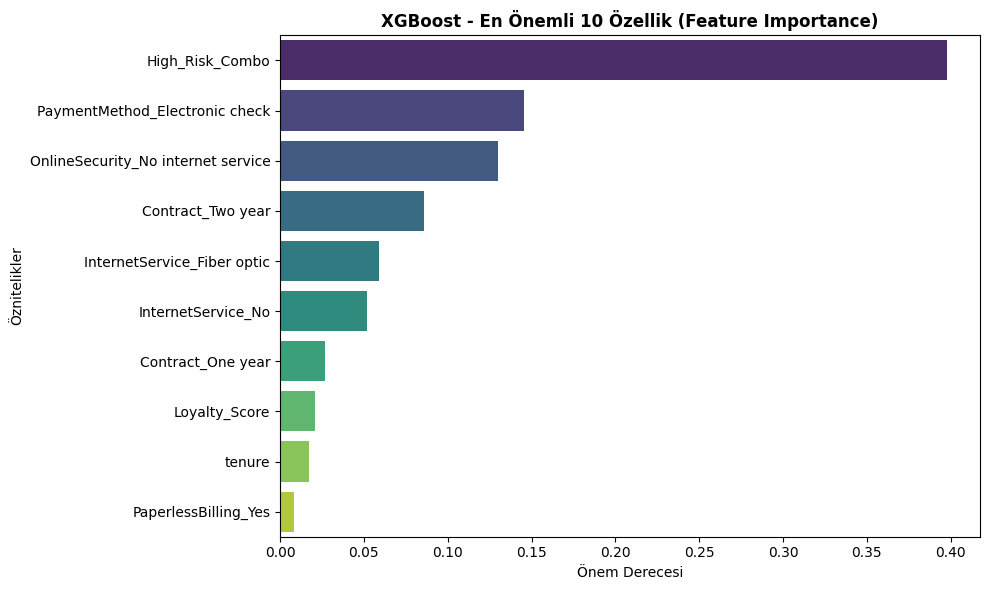

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 8. Feature Importance (Öznitelik Önemi) - XGBoost ---")

# XGBoost modelimizin (döngüdeki son fold'dan kalan model) özellik önem sıralamasını alıyoruz
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(10, 6))
# En önemli 10 değişkeni çizdiriyoruz
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(10), palette="viridis")
plt.title('XGBoost - En Önemli 10 Özellik (Feature Importance)', fontweight='bold')
plt.xlabel("Önem Derecesi")
plt.ylabel("Öznitelikler")
plt.tight_layout()
plt.show()

1. PaymentMethod_Electronic check (Elektronik Çek): Bu özellik açık ara şovu çalmış. Demek ki bu ödeme yöntemini kullanan müşterilerin davranışlarında (muhtemelen yüksek kaçış) devasa bir sinyal var.

2. InternetService_Fiber optic: Fiber internet kullananlar ikinci en büyük risk veya sadakat grubunu oluşturuyor.

3. Contract_Two year: 2 yıllık sözleşmesi olanlar (ki EDA grafiğinde en az churn olan gruptu) karar ağaçlarının en güçlü dallarından biri olmuş.